### MLOps Assignment 2 : Design and implement an end-to-end MLOps pipeline for model building, artifact/image creation, packaging, containerization, and CI/CD-based deployment using open-source tools

### Use case : 

Binary image classification (Cats vs Dogs) for a pet adoption platform.

### Group ID: 82
### Group members

| Name           | Email                                       | Student ID   | Contribution |
|----------------|---------------------------------------------|--------------|--------------|
| JAIDEEP PALIT  | 2024aa05319@wilp.bits-pilani.ac.in          | 2024aa05319  | 100%         |
|  OMKAR ANIL KUMAR | 2024ac05308@wilp.bits-pilani.ac.in         | 2024ac05308 |100%|
|  PALLAB KUMAR GHOSHAL  | 2024ab05312@wilp.bits-pilani.ac.in         | 2024ab05312 |100%|
|PANKAJ KUMAR  |2024ab05026@wilp.bits-pilani.ac.in   |2024ab05026|100%|
|PRASANNA B|2024ab05310@wilp.bits-pilani.ac.in|2024ab05310|100%|

### Problem Statement

Design and implement an end-to-end MLOps pipeline for model building, artifact/image creation, packaging, containerization, and CI/CD-based deployment using open-source tools

### Dataset:
Title: Cats and Dogs classification dataset

Source: CATS and Dogs binary classification dataset from Kaggle - https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset



### Task 1: Data Acquisition, Preprocessing & Exploratory Data Analysis (EDA)

Obtain the dataset. Pre-process to 224x224 RGB images for standard CNNs. Perform EDA with professional visualizations (histograms, correlation heatmaps, class balance).

#### Import Libraries

In [18]:
!pip install -r ../requirements.txt

#### Download the Dataset

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
from preprocess.preprocess import download_dataset
data_dir=download_dataset(url="bhavikjikadara/dog-and-cat-classification-dataset",download_path="cats_and_dogs_classification_data")

Path to dataset files: /home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/data/raw/cats_and_dogs_classification_data


#### Exploratory Data Analysis (EDA)

/home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/src/preprocess/eda.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='label', palette='magma')


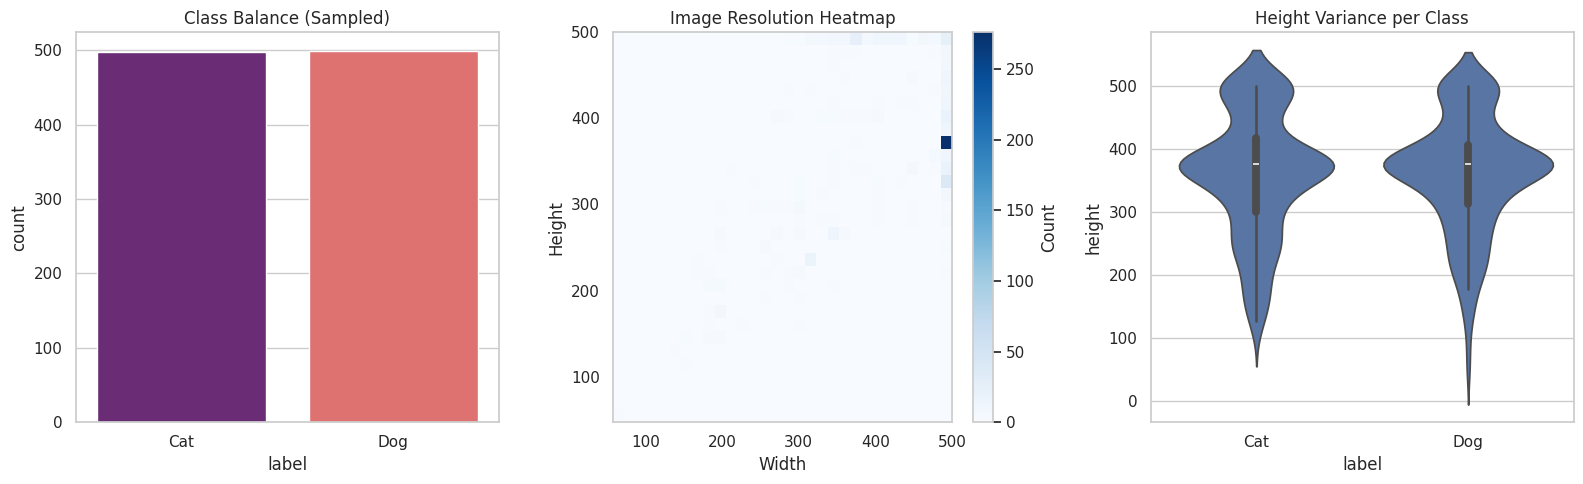

In [10]:
from preprocess.eda import eda_class_bal_image_res_channel_check
eda_class_bal_image_res_channel_check(data_dir=data_dir)


Analyzing Dog: 100%|██████████| 1000/1000 [00:00<00:00, 2609.80it/s]


<Figure size 1000x800 with 0 Axes>

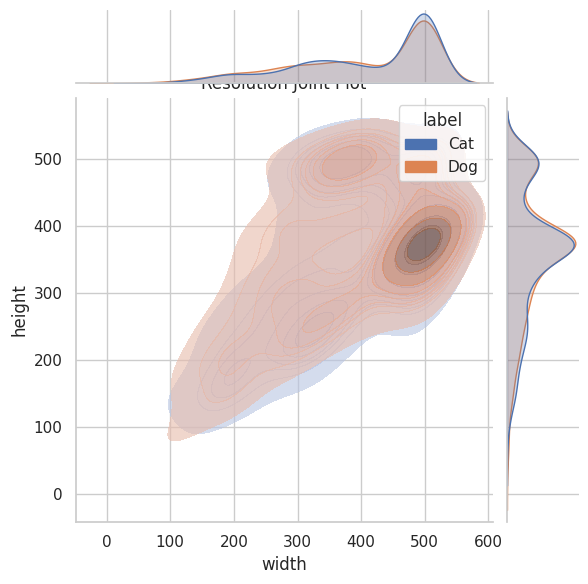

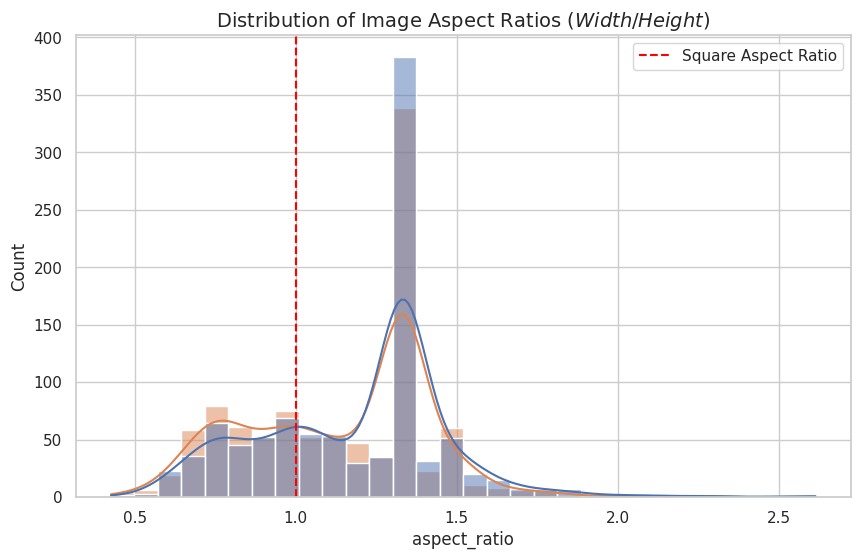

In [11]:
from preprocess.eda import perform_eda_res_disjoint_aspect_ratio
df_stats = perform_eda_res_disjoint_aspect_ratio(data_dir)


### Pre-process to 224x224 RGB images for standard CNNs
#### Train–Test Split

In [23]:
from preprocess.preprocess import pre_process_dataset
pre_process_dataset(data_dir=data_dir)

Processing Dog for test: 100%|██████████| 1250/1250 [00:00<00:00, 1420.97it/s]


✅ Dataset saved successfully at: /home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/data/preprocessed/preprocessed_cats_dogs_images


##### Data versioning with DVC

In [2]:
from preprocess.preprocess import data_versioning_with_dvc
data_versioning_with_dvc()


Running: dvc remote add -f origin s3://dvc


Running: dvc remote modify origin endpointurl https://dagshub.com/jaideep.palit/bits-mtech-mlops-assignment-2.s3


Running: dvc remote modify origin --local access_key_id d85f991495a6411e956277b0781bd119dfac225d


Running: dvc remote modify origin --local secret_access_key d85f991495a6411e956277b0781bd119dfac225d


Running: dvc add /home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/data/preprocessed/preprocessed_cats_dogs_images

To track the changes with git, run:

	git add ../data/preprocessed/preprocessed_cats_dogs_images.dvc

To enable auto staging, run:

	dvc config core.autostage true


Running: dvc push -r origin
Everything is up to date.


DVC setup completed successfully


### Model Building
Implement at least one baseline model (e.g., simple CNN or logistic regression on flattened pixels).
Save the trained model in a standard serialized format (e.g., .pkl, .pt, .h5).

##### Load dataset for training

In [2]:
from train.train_util import load_training_dataset
train_ds,val_ds=load_training_dataset()

Found 19953 files belonging to 2 classes.
Found 2498 files belonging to 2 classes.


In [3]:
from train.train_cnn import build_cnn,train_cnn,compile_model
cnn_model=build_cnn()
compile_model(cnn_model)


In [15]:
cnn_model.summary()

Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 112, 112, 32)   │         1,344 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 56, 56, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 28, 28, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 14, 14, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 246,309 (962.15 KB)

 Trainable params: 81,761 (319.38 KB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 163,524 (638.77 KB)

In [4]:
history=train_cnn(model=cnn_model,train_ds=train_ds,val_ds=val_ds)


Epoch 1/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.6281 - auc: 0.6782 - loss: 0.6940 - precision: 0.6387 - recall: 0.6058

624/624 ━━━━━━━━━━━━━━━━━━━━ 152s 241ms/step - accuracy: 0.6600 - auc: 0.7179 - loss: 0.6632 - precision: 0.6750 - recall: 0.6166 - val_accuracy: 0.7058 - val_auc: 0.7832 - val_loss: 0.6102 - val_precision: 0.8079 - val_recall: 0.5393 - learning_rate: 0.0010
Epoch 2/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 190s 222ms/step - accuracy: 0.7277 - auc: 0.7981 - loss: 0.5860 - precision: 0.7463 - recall: 0.6896 - val_accuracy: 0.6373 - val_auc: 0.8072 - val_loss: 0.7906 - val_precision: 0.9318 - val_recall: 0.2957 - learning_rate: 0.0010
Epoch 3/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7491 - auc: 0.8265 - loss: 0.5483 - precision: 0.7596 - recall: 0.7341

624/624 ━━━━━━━━━━━━━━━━━━━━ 143s 229ms/step - accuracy: 0.7555 - auc: 0.8333 - loss: 0.5391 - precision: 0.7664 - recall: 0.7350 - val_accuracy: 0.7586 - val_auc: 0.8707 - val_loss: 0.5180 - val_precision: 0.8636 - val_recall: 0.6138 - learning_rate: 0.0010
Epoch 4/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 130s 209ms/step - accuracy: 0.7927 - auc: 0.8671 - loss: 0.4896 - precision: 0.8005 - recall: 0.7795 - val_accuracy: 0.7034 - val_auc: 0.8892 - val_loss: 0.6312 - val_precision: 0.9424 - val_recall: 0.4327 - learning_rate: 0.0010
Epoch 5/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 124s 199ms/step - accuracy: 0.8127 - auc: 0.8915 - loss: 0.4476 - precision: 0.8169 - recall: 0.8060 - val_accuracy: 0.6793 - val_auc: 0.8999 - val_loss: 0.8030 - val_precision: 0.9608 - val_recall: 0.3734 - learning_rate: 0.0010
Epoch 6/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 152s 243ms/step - accuracy: 0.8243 - auc: 0.9053 - loss: 0.4211 - precision: 0.8271 - recall: 0.8200 - val_accuracy: 0.6713 - val_auc: 0.8933 - val_loss: 0.8283 

624/624 ━━━━━━━━━━━━━━━━━━━━ 183s 294ms/step - accuracy: 0.8550 - auc: 0.9291 - loss: 0.3698 - precision: 0.8554 - recall: 0.8544 - val_accuracy: 0.8591 - val_auc: 0.9379 - val_loss: 0.3547 - val_precision: 0.8384 - val_recall: 0.8894 - learning_rate: 5.0000e-04
Epoch 8/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 127s 203ms/step - accuracy: 0.8676 - auc: 0.9397 - loss: 0.3433 - precision: 0.8663 - recall: 0.8694 - val_accuracy: 0.8495 - val_auc: 0.9392 - val_loss: 0.3907 - val_precision: 0.9386 - val_recall: 0.7476 - learning_rate: 5.0000e-04
Epoch 9/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 141s 227ms/step - accuracy: 0.8772 - auc: 0.9464 - loss: 0.3251 - precision: 0.8760 - recall: 0.8786 - val_accuracy: 0.8531 - val_auc: 0.9428 - val_loss: 0.3630 - val_precision: 0.8087 - val_recall: 0.9247 - learning_rate: 5.0000e-04
Epoch 10/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 137s 219ms/step - accuracy: 0.8857 - auc: 0.9524 - loss: 0.3077 - precision: 0.8830 - recall: 0.8892 - val_accuracy: 0.8503 - val_auc: 0.9408 - val_

624/624 ━━━━━━━━━━━━━━━━━━━━ 136s 217ms/step - accuracy: 0.8957 - auc: 0.9616 - loss: 0.2795 - precision: 0.8930 - recall: 0.8990 - val_accuracy: 0.8791 - val_auc: 0.9535 - val_loss: 0.3133 - val_precision: 0.8530 - val_recall: 0.9159 - learning_rate: 2.5000e-04
Epoch 12/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.9030 - auc: 0.9657 - loss: 0.2650 - precision: 0.9009 - recall: 0.9056 - val_accuracy: 0.8455 - val_auc: 0.9511 - val_loss: 0.3967 - val_precision: 0.7824 - val_recall: 0.9567 - learning_rate: 2.5000e-04
Epoch 13/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 132s 212ms/step - accuracy: 0.9118 - auc: 0.9702 - loss: 0.2481 - precision: 0.9083 - recall: 0.9160 - val_accuracy: 0.8759 - val_auc: 0.9482 - val_loss: 0.3387 - val_precision: 0.8569 - val_recall: 0.9022 - learning_rate: 2.5000e-04
Epoch 14/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9068 - auc: 0.9677 - loss: 0.2569 - precision: 0.9039 - recall: 0.9116

624/624 ━━━━━━━━━━━━━━━━━━━━ 132s 212ms/step - accuracy: 0.9106 - auc: 0.9701 - loss: 0.2483 - precision: 0.9074 - recall: 0.9145 - val_accuracy: 0.8887 - val_auc: 0.9549 - val_loss: 0.3031 - val_precision: 0.8962 - val_recall: 0.8790 - learning_rate: 2.5000e-04
Epoch 15/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 131s 210ms/step - accuracy: 0.9161 - auc: 0.9738 - loss: 0.2347 - precision: 0.9134 - recall: 0.9192 - val_accuracy: 0.8227 - val_auc: 0.9542 - val_loss: 0.4448 - val_precision: 0.7480 - val_recall: 0.9728 - learning_rate: 2.5000e-04
Epoch 16/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 150s 223ms/step - accuracy: 0.9204 - auc: 0.9753 - loss: 0.2278 - precision: 0.9198 - recall: 0.9211 - val_accuracy: 0.8671 - val_auc: 0.9546 - val_loss: 0.3583 - val_precision: 0.9379 - val_recall: 0.7861 - learning_rate: 2.5000e-04
Epoch 17/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 132s 212ms/step - accuracy: 0.9247 - auc: 0.9774 - loss: 0.2191 - precision: 0.9217 - recall: 0.9282 - val_accuracy: 0.8763 - val_auc: 0.9555 - va

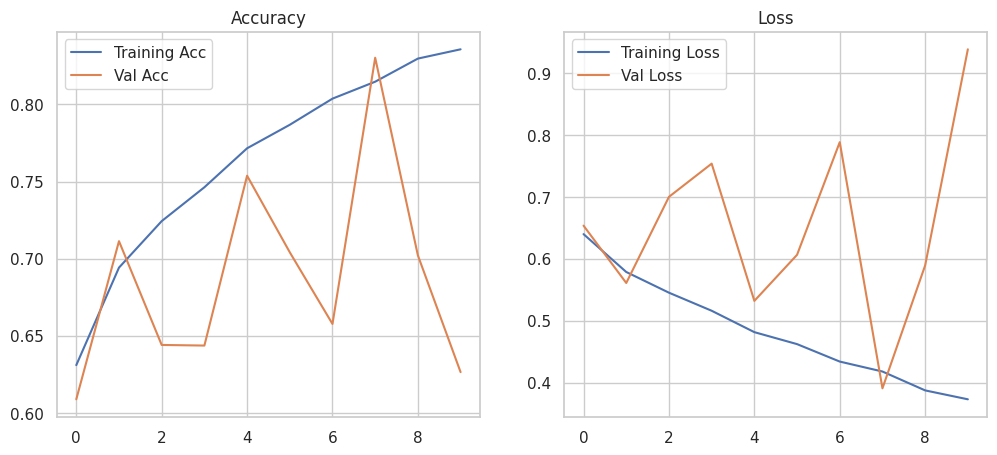

In [30]:
from train.train_cnn import plot_results
plot_results(history)

#### Evaluate Model with test dataset

In [5]:
from train.train_util import load_test_dataset
test_ds= load_test_dataset()

Found 2495 files belonging to 2 classes.


In [6]:
from evaluate.evaluate import evaluate_cnn
y_true, y_probs, y_pred=evaluate_cnn(model=cnn_model,test_ds=test_ds)

 1/78 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step

2026-02-21 20:53:40.354560: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step


#### Confusion Matrix

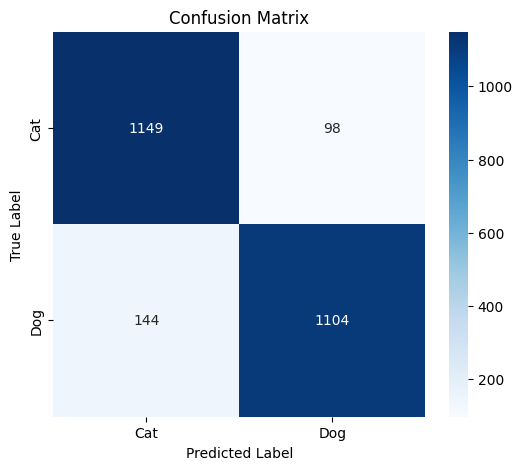

In [7]:
from evaluate.evaluate import plot_cnn_confusion_matrix
plot_cnn_confusion_matrix(y_true, y_pred)

#### ROC Curve and AUC

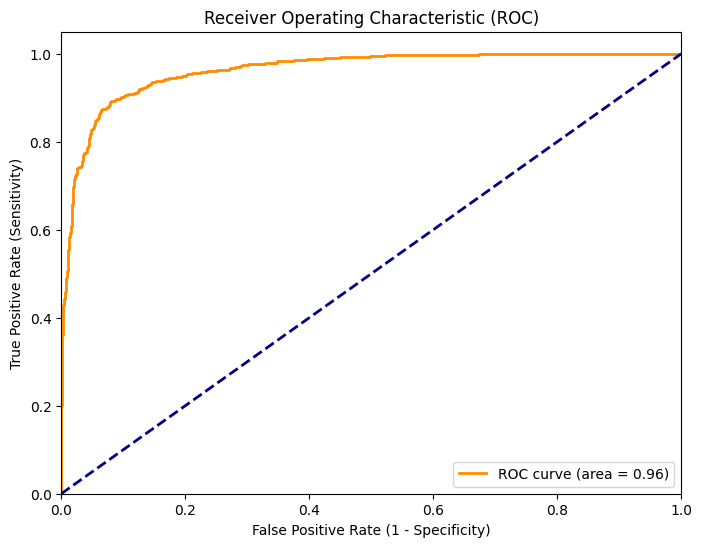

In [8]:
from evaluate.evaluate import plot_cnn_roc_curve
roc_auc=plot_cnn_roc_curve(y_true,y_probs)

#### Summary Metrics Table

------------------------------
Final Test Evaluation:
------------------------------
Accuracy:  0.9030
Precision: 0.9185
Recall:    0.8846
F1-Score:  0.9012
ROC-AUC:   0.9627
------------------------------


/home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/src/evaluate/evaluate.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metrics_names, y=metrics_values, palette=palette)


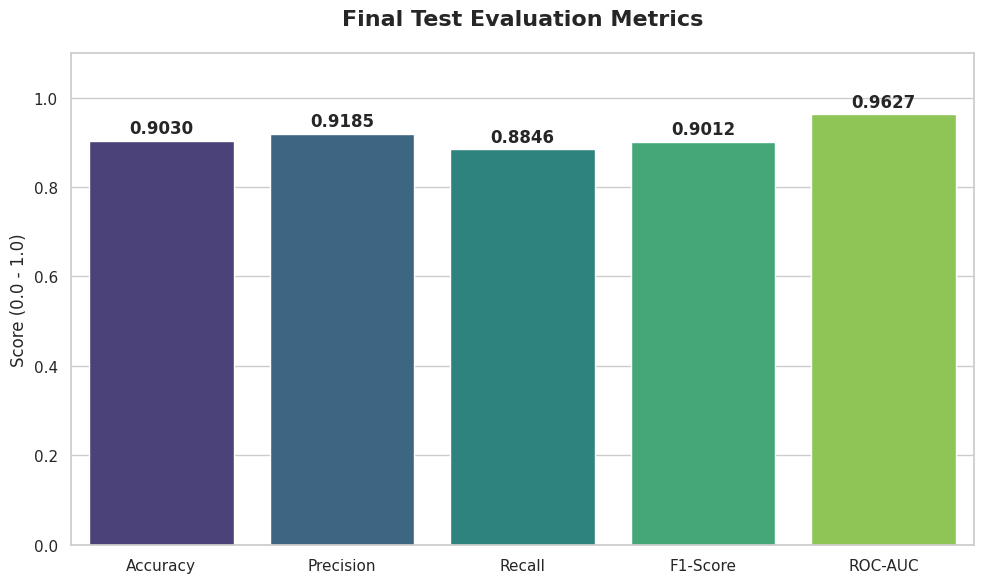

In [9]:
from evaluate.evaluate import plot_cnn_summary
metrics_values=plot_cnn_summary(y_true, y_pred, roc_auc)


### Experiment Tracking

Integrate MLflow (or a similar tool) for experiment tracking. Log parameters, metrics, artifacts, and plots for all runs.

#### Logging Plots as MLflow Artifacts

##### Initializing MLFlow

In [12]:
from evaluate.experiment_tracking import init_mlflow, mlflow_end_run

init_mlflow()
mlflow_end_run()

##### Log EDA plots

In [13]:
from evaluate.experiment_tracking import mlflow_eda
mlflow_eda()

##### CNN – MLflow Tracking

In [14]:
from evaluate.experiment_tracking import mlflow_cnn

mlflow_cnn(cnn_model=cnn_model,metrics=metrics_values)

Model summary logged to MLflow artifacts.
Logged CNN run


##### End MlFlow run

In [16]:
from evaluate.experiment_tracking import mlflow_end_run
mlflow_end_run()

### Model Packaging & Reproducibility

##### Save CNN

In [17]:
from train.train_util import save_model
save_model("cnn_model.pkl",cnn_model)
print("CNN model saved")

CNN model saved


##### Load CNN Model (Reusability Check)

##### Reproducible Preprocessing Pipeline

In [19]:
from train.train_util import load_model
loaded_cnn_model=load_model("cnn_model.pkl")
print("CNN model loaded successfully")

CNN model loaded successfully


/home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 30 variables whereas the saved optimizer has 58 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [20]:
loaded_cnn_model.summary()

Model: "cnn_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 112, 112, 32)   │         1,344 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 56, 56, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 28, 28, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 14, 14, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 164,548 (642.77 KB)

 Trainable params: 81,761 (319.38 KB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 81,763 (319.39 KB)

##### Perform Test Inference with Sample Data

In [21]:
from evaluate.evaluate import get_sample_test_data
cat_img, dog_img=get_sample_test_data()

##### CNN Prediction

In [22]:
from evaluate.evaluate import get_prediction
import os

results = [("Actual Cat", cat_img), ("Actual Dog", dog_img)]

for actual, path in results:
    pred_label, conf, prob = get_prediction(loaded_cnn_model,path)
    print(f"--- Testing {actual} ---")
    print(f"File: {os.path.basename(path)}")
    print(f"Predicted Label: {pred_label}")
    print(f"Confidence:      {conf:.2%}")
    print(f"Raw Probability: {prob:.4f}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
--- Testing Actual Cat ---
File: 12189.jpg
Predicted Label: Cat
Confidence:      99.40%
Raw Probability: 0.0060

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
--- Testing Actual Dog ---
File: 12189.jpg
Predicted Label: Dog
Confidence:      99.89%
Raw Probability: 0.9989

